Project: Independent Project, QSBSC
Author: Olivia Feehan-Nelson


Cancer cells of solid tumors rely on heterogeneity within the tumor for survival. At the forefront of this complexity, is the immune tumor microenvironment (iTME). The iTME is an assembly of tumor, immune cells, stromal cells, and extracellular matrix, which arranges in complex organization of the above listed components, which allow for increased antitumor immunity. More research must be done to elucidate the function of the organization of the iTME in treatment resistance of solid tumors. Co-detection by indexing (CODEX) is a powerful multiplexing tool that allows the identification of cell expression, and subsequently categorization of cellular types, through the use of DNA-conjugated antibodies to fluorescently probe mRNA in fixed samples. Much has been studied regarding the cell type and gene expression within the tumor microenvironment, but it has yet to be explored the impact that cellular interactions and organization have on the function of the iTME. Schurch et al., used CODEX in frozen tissue samples of colorectal tumors to identify cellular neighborhoods within the tissue to try to elucidate function and organization of the iTME.

Schurch et al., in figure 6G uses a correlation matrix, or heatmap, to identify differentiatal enrichment of cell types in cellular neighborhoods by clustering data from both CLR and DII patient types. This plot aimed to elucidate any differences in the functions of the neighborhoods in different tumor types. Markdown comments refer to the code written below.

In [32]:
from tensorly.decomposition import non_negative_parafac,parafac,non_negative_tucker
from tensorly.regression import KruskalRegressor
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.stats import ttest_ind
from sklearn.utils import resample
import itertools
from scipy.stats import spearmanr, ttest_ind
import seaborn as sns
%pylab inline

Populating the interactive namespace from numpy and matplotlib


/home/graham/anaconda3/envs/hier/lib/python3.7/site-packages/IPython/core/magics/pylab.py:160: UserWarning: pylab import has clobbered these variables: ['f']
`%matplotlib` prevents importing * from pylab and numpy
  "\n`%matplotlib` prevents importing * from pylab and numpy"


import the dataset using pickle, which takes a data frame and makes it binary, and name it "cells2"

In [ ]:
cells2 = pd.read_pickle('cells2_salil')

Read data frames in.
Define and index variables. 

In [34]:
ct_frq = pd.read_pickle('cell_type_freqs_per_patient')
chk_frq = pd.read_pickle('checkpoint_to_parent_freqs_perneighborhood_perpatient')
neigh_frqs = pd.read_pickle('neigh_freqs_per_patient')
all_frqs = pd.read_pickle('allcell_type_counts_perneighborhood_perpatient')

annotations = pd.read_csv('blocknumb_to_patient_no.csv')
survival = pd.read_csv('updated_survival.csv', header = 1)
annotations['B-Number'] = annotations['B-Number'].astype(str)
survival['Probenummer_Original'] = survival['Probenummer_Original'].astype(str)
# i checked that the indexes are the same (B numbers warped)
annotations['OS'] = survival['OS'].loc[annotations.index.values]
annotations['OS_censor'] = survival['OS_Censor'].loc[annotations.index.values]
annotations['DFS'] = survival['DFS'].loc[annotations.index.values]
annotations['DFS_censor'] = survival['DFS_Censor'].loc[annotations.index.values]
annotations = annotations.set_index('Patient')
good_patients = annotations[~annotations['OS'].isna()].index.values
#good_patients = good_patients[annotations['DFS'].loc[good_patients]>0]
annotations['B-Number'].to_csv('BN')
group = (annotations['Group'].loc[good_patients]==2).astype(int) # 
(annotations['Group'].loc[good_patients]==2).astype(int).to_csv('group')

Combine cells that are expressing (or not expressing) two markers to define cell types 

In [35]:
# cells = ['CD4+ T cells CD45RO+',
#  'granulocytes',
#  'vasculature',
#  'plasma cells',
#  'stroma',
#  'tumor cells',
#  'CD68+CD163+ macrophages',
#  'CD8+ T cells',
#  'smooth muscle']
cells =  cells2['ClusterName'].unique()
parents = {'CD4+ICOS+':'CD4+',
 'CD4+Ki67+':'CD4+',
 'CD4+PD-1+':'CD4+',
 'CD68+CD163+ICOS+':'CD68+CD163+',
 'CD68+CD163+Ki67+':'CD68+CD163+',
 'CD68+CD163+PD-1+':'CD68+CD163+',
 'CD68+ICOS+':'CD68+',
 'CD68+Ki67+':'CD68+',
 'CD68+PD-1+':'CD68+',
 'CD8+ICOS+':'CD8+',
 'CD8+Ki67+':'CD8+',
 'CD8+PD-1+':'CD8+',
 'Treg-ICOS+':'CD25+FOXP3+',
 'Treg-Ki67+':'CD25+FOXP3+',
 'Treg-PD-1+':'CD25+FOXP3+'}

frq_chks = ['freq.CD4+ICOS+', 'freq.CD4+Ki67+',  'freq.CD4+PD-1+','freq.CD68+CD163+ICOS+', 
    'freq.CD68+CD163+Ki67+', 'freq.CD68+CD163+PD-1+','freq.CD68+ICOS+', 'freq.CD68+Ki67+','freq.CD68+PD-1+',
    'freq.CD8+ICOS+', 'freq.CD8+Ki67+',  'freq.CD8+PD-1+','freq.Treg-ICOS+', 'freq.Treg-Ki67+',
    'freq.Treg-PD-1+' ]
chks = [a.split('.')[1] for a in frq_chks ]



Creating 2 variables, first grouped patients and neighborhoods, excluding NAs
2nd, patient counts 

In [36]:
nbd_counts = cells2.groupby(['patients','neighborhood10']).size().unstack().fillna(0).loc[good_patients]
pat_counts = cells2.groupby(['patients']).size().fillna(0).loc[good_patients]


defining normalize(x) as their values across the data frame

In [37]:
def normalize(X):
    arr = np.array(X.fillna(0).values)
    return pd.DataFrame(np.log2(1e-5 + arr/arr.sum(axis =1, keepdims = True)), index = X.index.values, columns = X.columns).fillna(0)


define neighborhood names, use normalize function to normalize neighborhood to patient counts
concatenate neighborhood and patients, filling NAs with 0

In [38]:
# data prep
nbs = [0,2,3,4,6,7,8,9]
X_cts = normalize(ct_frq.reset_index().iloc[:,1:].set_index('patients').loc[good_patients,cells])

# X_neighs = add_constant(normalize(neigh_frqs.reset_index().iloc[:,1:].set_index('patients').loc[good_patients,nbs]))

x = all_frqs.reset_index().iloc[:,1:]
X_all = normalize(pd.concat([x.loc[x['neighborhood10']==nb,:].set_index('patients').loc[good_patients,cells].rename({col: col+'_'+str(nb) for col in cells},axis = 1) for nb in nbs], axis = 1))

# X_all.to_csv('X_all')
# X_cts.to_csv('X_cts')
# X_neighs.to_csv('X_neighs')

Y =  np.maximum(annotations['OS'].loc[good_patients],0.01)
censor = annotations['OS_censor'].loc[good_patients]

censor.to_csv('censor')
# Y.to_csv('Y')


x = all_frqs.reset_index().iloc[:,1:]
norm = (pd.concat([x.loc[x['neighborhood10']==nb,:].set_index('patients').loc[good_patients,cells].rename({col: col+'_'+str(nb) for col in cells},axis = 1) for nb in nbs], axis = 1))
ctf =all_frqs.reset_index().iloc[:,1:]
ctf = ctf[ctf['neighborhood10'].isin(nbs)].groupby('patients').apply(lambda x:x.sum(axis=0)).iloc[:,2:].loc[good_patients]
X_cond_all =np.vstack([(1+norm[col].values)/(1+ctf[col.split('_')[0]].values) for col in norm.columns]).T
X_cond_all = np.log(1e-3+pd.DataFrame(X_cond_all, columns = norm.columns, index = norm.index.values).fillna(0))
# X_cond_all.to_csv('X_cond_all')


nbs = [0,2,3,4,5,6,7,8,9]
norm = (pd.concat([x.loc[x['neighborhood10']==nb,:].set_index('patients').loc[good_patients,cells].rename({col: col+'_'+str(nb) for col in cells},axis = 1) for nb in nbs], axis = 1))
X_condnb_all =np.vstack([(1+norm[col].values)/(1+nbd_counts[int(col.split('_')[1])].values) for col in norm.columns]).T
X_condnb_all = np.log(1e-3+pd.DataFrame(X_condnb_all, columns = norm.columns, index = norm.index.values).fillna(0))
X_condnb_all = X_condnb_all.loc[:,X_condnb_all.apply(np.std, axis =0)>0]
# X_condnb_all.to_csv('X_condnb_all')






/home/graham/anaconda3/envs/hier/lib/python3.7/site-packages/ipykernel_launcher.py:2: FutureWarning: 
Passing list-likes to .loc or [] with any missing label will raise
KeyError in the future, you can use .reindex() as an alternative.

See the documentation here:
https://pandas.pydata.org/pandas-docs/stable/indexing.html#deprecate-loc-reindex-listlike
  
/home/graham/anaconda3/envs/hier/lib/python3.7/site-packages/ipykernel_launcher.py:7: FutureWarning: 
Passing list-likes to .loc or [] with any missing label will raise
KeyError in the future, you can use .reindex() as an alternative.

See the documentation here:
https://pandas.pydata.org/pandas-docs/stable/indexing.html#deprecate-loc-reindex-listlike
  import sys
/home/graham/anaconda3/envs/hier/lib/python3.7/site-packages/ipykernel_launcher.py:21: FutureWarning: 
Passing list-likes to .loc or [] with any missing label will raise
KeyError in the future, you can use .reindex() as an alternative.

See the documentation here:
https://pan

In [30]:
# data prep
x = chk_frq[frq_chks].reset_index().iloc[:,1:].fillna(0)
X_chk_all = np.log(1e-3+pd.concat([x.loc[x['neighborhood10']==nb,:].set_index('patients').loc[good_patients,frq_chks].rename({col: col+'_'+str(nb) for col in frq_chks},axis = 1) for nb in nbs], axis = 1).fillna(0))
X_chk_all = X_chk_all.loc[:,X_chk_all.apply(np.std, axis =0)>0]
X_chk_all.to_csv('X_chk_all')


x = all_frqs.reset_index().iloc[:,1:]
totals = x.groupby('patients').apply(lambda x: x.sum(axis = 0)).loc[good_patients]
X_chk_overall =np.log(1e-3+ pd.DataFrame(np.stack([totals[chk].values/totals[parents[chk]].values for chk in chks]).T, columns = frq_chks, index = good_patients))
X_chk_overall.to_csv('X_chk_overall_parent')

x = all_frqs.reset_index().iloc[:,1:]
totals = x.groupby('patients').apply(lambda x: x.sum(axis = 0)).loc[good_patients]
X_chk_overall =np.log(1e-3+ pd.DataFrame(np.stack([totals[chk].values/pat_counts.values for chk in chks]).T, columns = frq_chks, index = good_patients))
X_chk_overall.to_csv('X_chk_overall_pat')


df_list = []
for nb in nbs:
    arr = x.loc[x['neighborhood10']==nb,:].set_index('patients').loc[good_patients,chks].values
    arr /= nbd_counts[nb].values[:,None]
    df_list.append(pd.DataFrame(arr, index = good_patients, columns = [chk+'_'+str(nb) for chk in chks]).fillna(0))
    
X_density = pd.concat(df_list, axis = 1)

X_density = np.log(1e-3+X_density.loc[:, X_density.apply(np.std,axis = 0)>0])
X_density.to_csv('X_chk_density')




/home/graham/anaconda3/envs/hier/lib/python3.7/site-packages/ipykernel_launcher.py:2: FutureWarning: 
Passing list-likes to .loc or [] with any missing label will raise
KeyError in the future, you can use .reindex() as an alternative.

See the documentation here:
https://pandas.pydata.org/pandas-docs/stable/indexing.html#deprecate-loc-reindex-listlike
  
/home/graham/anaconda3/envs/hier/lib/python3.7/site-packages/ipykernel_launcher.py:20: FutureWarning: 
Passing list-likes to .loc or [] with any missing label will raise
KeyError in the future, you can use .reindex() as an alternative.

See the documentation here:
https://pandas.pydata.org/pandas-docs/stable/indexing.html#deprecate-loc-reindex-listlike


import another statistical package to do the correlation/heatmap modeling

In [11]:
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests as mpt

Plot the headmap using the heatmap function after further arranging the data. add a * for values where p<0.5

/home/graham/anaconda3/envs/hier/lib/python3.7/site-packages/ipykernel_launcher.py:11: FutureWarning: 
Passing list-likes to .loc or [] with any missing label will raise
KeyError in the future, you can use .reindex() as an alternative.

See the documentation here:
https://pandas.pydata.org/pandas-docs/stable/indexing.html#deprecate-loc-reindex-listlike
  # This is added back by InteractiveShellApp.init_path()


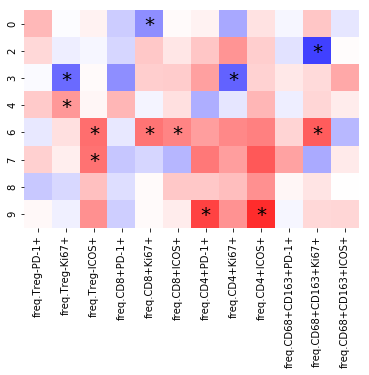

In [21]:
frq_chks = ['freq.Treg-PD-1+','freq.Treg-Ki67+','freq.Treg-ICOS+','freq.CD8+PD-1+','freq.CD8+Ki67+','freq.CD8+ICOS+','freq.CD4+PD-1+','freq.CD4+Ki67+','freq.CD4+ICOS+','freq.CD68+CD163+PD-1+','freq.CD68+CD163+Ki67+','freq.CD68+CD163+ICOS+']
chks = [a.split('.')[1] for a in frq_chks ]
nbs = [0,2,3,4,6,7,8,9]
x = all_frqs.reset_index().iloc[:,1:]
x = x.loc[x['neighborhood10'].isin(nbs),:]
totals = x.groupby('patients').apply(lambda x: x.sum(axis = 0)).loc[good_patients]
X_chk_overall =np.log(1e-3+ pd.DataFrame(np.stack([totals[chk].values/pat_counts.values for chk in chks]).T, columns = frq_chks, index = good_patients))

df_list = []
for nb in nbs:
    arr = x.loc[x['neighborhood10']==nb,:].set_index('patients').loc[good_patients,chks].values
    arr /= nbd_counts[nb].values[:,None]
    df_list.append(pd.DataFrame(arr, index = good_patients, columns = [chk+'_'+str(nb) for chk in chks]))
    
X_density = pd.concat(df_list, axis = 1)

X_density = np.log(1e-3+X_density.loc[:, X_density.apply(np.std,axis = 0)>0])

changes = {}
for col in X_chk_overall.columns:
    for nb in nbs:
        X = pd.concat([X_chk_overall[col], group.astype('int'),pd.Series(np.ones(len(group)), index = group.index.values)],axis = 1).values
        if col.split('.')[1]+'_%d'%nb in X_density.columns:
            Y = X_density[col.split('.')[1]+'_%d'%nb].values
            X = X[~pd.isna(Y)]
            Y = Y[~pd.isna(Y)]
            results = sm.OLS(Y,X).fit()
            changes[(col,nb)] = (results.pvalues[1], results.params[1])
        

dat = (pd.DataFrame(changes).loc[1].unstack())
dat = pd.DataFrame(np.nan_to_num(dat.values),index = dat.index, columns = dat.columns).T.sort_index(ascending=True).loc[:,frq_chks]
pvals = (pd.DataFrame(changes).loc[0].unstack()).T.sort_index(ascending=True).loc[:,frq_chks]


ax = sns.heatmap(dat,cmap = 'bwr', vmin = -1, vmax = 1,cbar=False)

for a,b in zip(*np.where (pvals<0.05)):
    plt.text(b+.5,a+.55,'*',fontsize = 20,ha = 'center',va = 'center')
#plt.savefig('revised_heatmap.pdf')

This heatmap aimed to answer the question if there are any expression differences between patient groups in the neighborhoods. Above is a heatmap showing the enrichment of cells at a p value of less than 0.5, where blue values are enriched for CLR tumors and red values are DII enriched. All neighborhoods exhibited differential enrichment, except the smooth muscle neighboorhood (8). The CLR enrichment of KI67+ cells in the T-cell enriched, bulk tumor, and immune-infiltrated stroma, could indicate a increase in aggressive division compared to DII tumor types, related to the folicles. Conversely, the enrichement of cells in neighborhood 6 could indicate that immunosuppresive activity is increased in DII patients. 

This analytical method allows the authors to determine if cell types are enriched (positively or negatively) in neighborhoods they previously defined. Neighborhoods 1-9 are, T-cell enriched, bulk tumor, immune-infiltrated stroma, macrophage enriched, follicle, tumor boundary, vascularized smooth muscle, smooth muscle, granulocyte enriched, respectively. One limitation to this particular analysis type is the confirmation bias that occurs when confirming the neighborhood enrichment and cell types. Because the analysis is extremely supervised, the data output needs to be taken with a grain of salt due. One other limitation to this analysis is the assumption that this gene expression is temporally stable. This snapshot in time could potentially misrepresent cellular neighborhoods by assuming the gene expression is stable. Presumably this limitation would be controlled by having multiple patient samples, but it is, while unlikely, remotely possible that gene expression could change after excission of the tumor before fixation. An interesting analysis to address this question could be to fix samples in a time course to determine if the cellular neighborhoods change as time from excision to fixation increases.Overall, I think this analysis is highly effective and informative; it helps to concisely represent the differences in cell type enrichment of the patient groups. 
